# Homework 6: Correlations.

*Instructions:*
Please answer the following questions and submit your work
by editing this jupyter notebook and submitting it on Canvas.
Questions may involve math, programming, or neither,
but you should make sure to *explain your work*:
i.e., you should usually have a cell with at least a few sentences
explaining what you are doing.

Also, please be sure to always specify units of any quantities that have units,
and label axes of plots (again, with units when appropriate).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
rng = np.random.default_rng()
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import make_pipeline

# 1. Ever Upwards

You are part of a team aiming to predict future costs for a coffee shop,
and are given the following model.
Let $X_0 = \$1.50$ be the price (to the shop) of a cup of coffee today,
and model the price $n$ weeks from now as $X_n = X_{n-1} + Z_n$,
where each $Z_n$ has a Normal distribution with mean \\$0.10 and standard deviation \\$0.10,
and is independent of other $Z$.
We want to see how well we can predict prices for the next 10 weeks under this model.

*(a)* If we define $Z = (Z_1, Z_2, \ldots, Z_{10})$,
    and $X = (X_1, X_2, \ldots, X_{10})$,
    then (taking $X$ and $Z$ to be column vectors)
    we can write $X = X_0 + AZ$ for some matrix $A$.
    What is that matrix?

- Since $X_n = X_0 + Z_1 + Z_2 + \ldots + Z_n$, we need a matrix $A$ such that $(AZ)_i = Z_1 + \ldots + Z_i$.  
- $A_{ij} = 1$ if $j \le i$ and $0$, $A$ is a $10 \times 10$ lower triangular matrix of ones, as constructed above.


*(b)* What is the mean and covariance matrix of $X$?
    Explain, and check by simulation.

$\mathbb{E}[X] = X_0 + A \cdot \mathbb{E}[Z]$

Since $\mathbb{E}[Z_i] = 0.10 \text{ , then } \mathbb{E}[Z] = 0.10 \text{(a 10D vector of 0.10s )}$

$\mathbb{E}[X] = 1.5 + A \cdot 0.10$

Covariance of X:

Since $Cov(Z) = 0.01 \cdot I $, then:

$\text{Cov(X)} = A \cdot \text{Cov(Z)} * A^T =0.1 * AA^T$

In [2]:
#a
n = 10
A = np.tril(np.ones((n, n)))
print(A)


[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 1. 1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 0. 0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1. 0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1. 1. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1. 1. 1. 0. 0. 0.]
 [1. 1. 1. 1. 1. 1. 1. 1. 0. 0.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 0.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]


In [3]:
#b 

X0 = 1.5
mu_Z = 0.10
sigma_Z = 0.10
n_sim = 100_000

# Theoretical mean: E[X_n] = X0 + n * mu_Z
mean_X_theory = X0 + A @ np.full(10, mu_Z)

# Theoretical covariance: Cov[X] = sigma^2 * A @ A.T
cov_X_theory = (sigma_Z**2) * A @ A.T

print("Theoretical Mean:\n", np.round(mean_X_theory, 4))
print("\nTheoretical Covariance Matrix:\n", np.round(cov_X_theory, 4))

# Verify by simulation
Z_sim = rng.normal(loc=mu_Z, scale=sigma_Z, size=(10, n_sim))
X_sim = X0 + A @ Z_sim

mean_X_sim = np.mean(X_sim, axis=1)
cov_X_sim = np.cov(X_sim)

print("\nSimulated Mean:\n", np.round(mean_X_sim, 4))
print("\nSimulated Covariance Matrix:\n", np.round(cov_X_sim, 4))

print("\nMax error (mean):", np.round(np.max(np.abs(mean_X_sim - mean_X_theory)), 5))
print("Max error (cov): ", np.round(np.max(np.abs(cov_X_sim - cov_X_theory)), 5))

Theoretical Mean:
 [1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5]

Theoretical Covariance Matrix:
 [[0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01]
 [0.01 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02]
 [0.01 0.02 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03]
 [0.01 0.02 0.03 0.04 0.04 0.04 0.04 0.04 0.04 0.04]
 [0.01 0.02 0.03 0.04 0.05 0.05 0.05 0.05 0.05 0.05]
 [0.01 0.02 0.03 0.04 0.05 0.06 0.06 0.06 0.06 0.06]
 [0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.07 0.07 0.07]
 [0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.08 0.08]
 [0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.09]
 [0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1 ]]

Simulated Mean:
 [1.6001 1.7001 1.8002 1.9002 2.0004 2.1008 2.2007 2.3001 2.4002 2.5002]

Simulated Covariance Matrix:
 [[0.01   0.0101 0.0101 0.0101 0.0101 0.0101 0.0101 0.01   0.01   0.0101]
 [0.0101 0.0201 0.0201 0.0201 0.0201 0.02   0.0201 0.02   0.0201 0.0201]
 [0.0101 0.0201 0.03   0.03   0.03   0.03   0.0301 0.03   0.0301 0.0301]
 [0.0101 0.0201 0.03   0.04   0.04 

Interpretation: The simulated results match theory closely — max error of 0.001, confirming our math is correct.

The mean rises from 1.60 to 2.50 (increasing 0.10 each week), which makes sense since 
each $Z_n$ adds 0.10 on average.

The covariance matrix shows all positive values, coffee prices across weeks move together 
because each week's price builds on the last. The variance also grows over time (0.01 → 0.10 
along the diagonal), meaning the further out we predict, the more uncertain the price becomes.

# 2. Books by a different name

In class, we did PCA on word count data from passages from three books. The passages are in the file [data/passages.txt](https://uodsci.github.io/dsci345/class_material/fall_2022/homeworks/data/passages.txt) and the sources of each passage are in [data/passage_sources.tsv](https://uodsci.github.io/dsci345/class_material/fall_2022/homeworks/data/passage_sources.tsv). Repeat the analysis. You may use the same code from class to read in and process the data,
but you should *use [scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)* to do the PCA.  Your results should be similar but not the same as those from class, since scikit-learn's implementation differs somewhat. Also, you don't need to show everything that we did in class
(use your judgement) but we encourage you to explore.

*Note:* part of this question is to figure out how what another method gives you maps on to what we discussed in class. Big clues are provided by the sizes of various outputs.

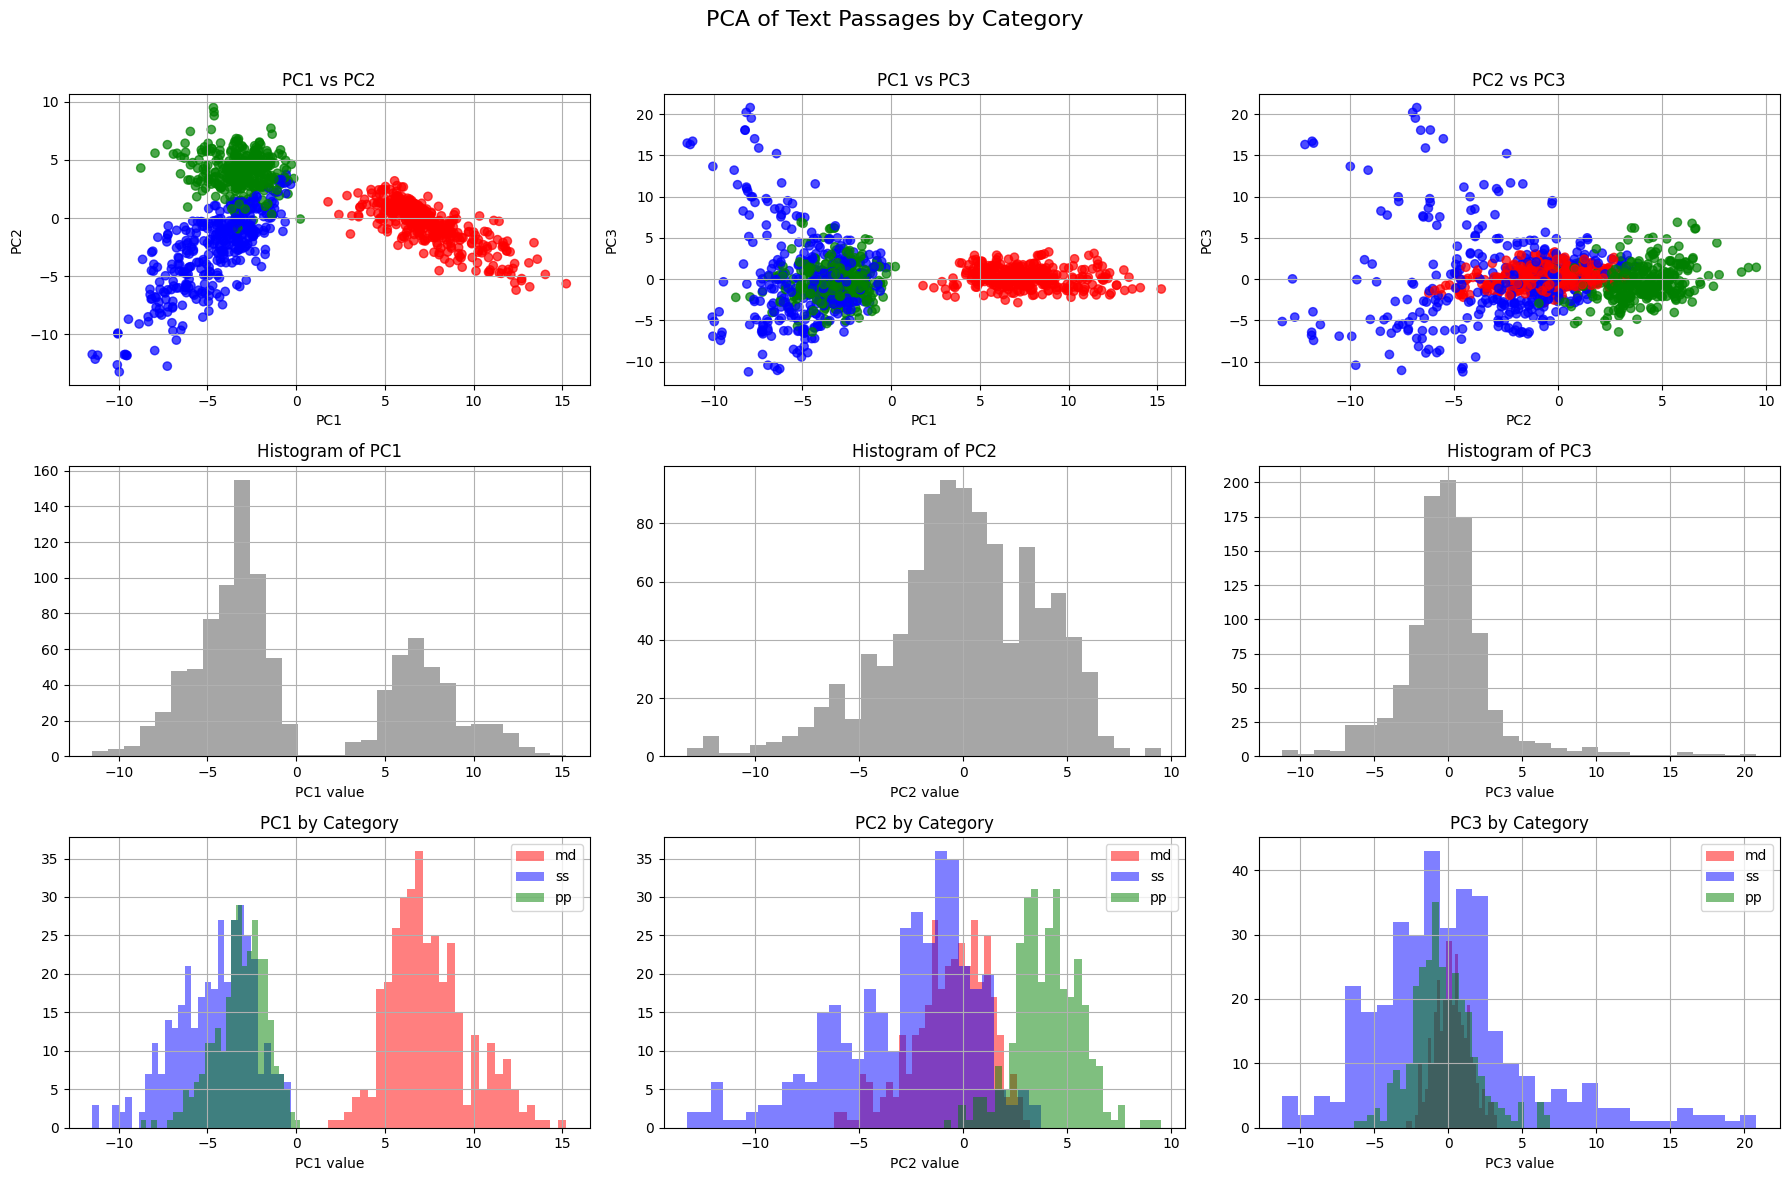

Explained Variance:
PC1: 3.40%
PC2: 1.37%
PC3: 1.23%
Total (PC1+PC2+PC3): 6.00%


In [4]:
# Load data
with open("passages.txt", "r", encoding="utf-8") as f:
    passages = f.read().strip().split("\n")

labels_df = pd.read_csv("passage_sources.tsv", sep="\t", header=0)
assert len(passages) == len(labels_df), "Mismatch in data lengths"

labels_df["passage"] = passages
categories = labels_df["source"]

# Vectorize
vectorizer = CountVectorizer(stop_words="english", max_features=1000)
X_counts = vectorizer.fit_transform(labels_df["passage"])

# PCA
scaler = StandardScaler(with_mean=False)
pca = PCA(n_components=3)
X_pca = make_pipeline(scaler, pca).fit_transform(X_counts.toarray())
explained = pca.explained_variance_ratio_

# Color mapping
color_map = {"md": "red", "ss": "blue", "pp": "green"}
colors = categories.map(color_map)

plt.figure(figsize=(18, 12))
plt.suptitle("PCA of Text Passages by Category", fontsize=16)

#Pairwise scatter plots
plt.subplot(3, 3, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.7)
plt.title("PC1 vs PC2")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)

plt.subplot(3, 3, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 2], c=colors, alpha=0.7)
plt.title("PC1 vs PC3")
plt.xlabel("PC1")
plt.ylabel("PC3")
plt.grid(True)

plt.subplot(3, 3, 3)
plt.scatter(X_pca[:, 1], X_pca[:, 2], c=colors, alpha=0.7)
plt.title("PC2 vs PC3")
plt.xlabel("PC2")
plt.ylabel("PC3")
plt.grid(True)

# Histograms of PCs
for i in range(3):
    plt.subplot(3, 3, 4 + i)
    plt.hist(X_pca[:, i], bins=30, alpha=0.7, color="gray")
    plt.title(f"Histogram of PC{i+1}")
    plt.xlabel(f"PC{i+1} value")
    plt.grid(True)

# Histograms split by category
for i in range(3):
    plt.subplot(3, 3, 7 + i)
    for cat, color in color_map.items():
        mask = (categories == cat).values
        plt.hist(X_pca[mask, i], bins=30, alpha=0.5, label=cat, color=color)
    plt.title(f"PC{i+1} by Category")
    plt.xlabel(f"PC{i+1} value")
    plt.grid(True)
    plt.legend()

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


print("Explained Variance:")
print(f"PC1: {explained[0]*100:.2f}%")
print(f"PC2: {explained[1]*100:.2f}%")
print(f"PC3: {explained[2]*100:.2f}%")
print(f"Total (PC1+PC2+PC3): {explained[:3].sum()*100:.2f}%")

In [5]:
loadings = pca.components_  
feature_names = vectorizer.get_feature_names_out()

for pc_idx, pc_name in enumerate(["PC1", "PC2", "PC3"]):
    top_pos = np.argsort(loadings[pc_idx])[-5:][::-1]
    top_neg = np.argsort(loadings[pc_idx])[:5]
    print(f"{pc_name} top positive words: {[feature_names[i] for i in top_pos]}")
    print(f"{pc_name} top negative words: {[feature_names[i] for i in top_neg]}")
    print()

PC1 top positive words: ['sea', 'like', 'ship', 'whale', 'ahab']
PC1 top negative words: ['mrs', 'elinor', 'sister', 'mother', 'miss']

PC2 top positive words: ['elizabeth', 'bennet', 'darcy', 'jane', 'bingley']
PC2 top negative words: ['elinor', 'marianne', 'jennings', 'mariannes', 'dashwood']

PC3 top positive words: ['john', 'sir', 'middleton', 'middletons', 'elegance']
PC3 top negative words: ['marianne', 'felt', 'mariannes', 'misery', 'letter']



Interpret: 
- The scatter plots show clear separation between all three books.
PCA has successfully identified distinct writing styles purely from word frequencies.

- PC1 separates Moby Dick (positive: 'sea', 'whale', 'ahab') from the Jane Austen novels 
(negative: 'mrs', 'mother', 'miss')  maritime vs domestic vocabulary.

- PC2 and PC3 then separate the two Austen novels from each other: PC2 picks up Pride & Prejudice ('elizabeth', 'darcy', 'bingley') while PC3 distinguishes Sense & Sensibility 
('middleton', 'elinor', 'dashwood').

- Together PC1–PC3 explain only 6% of total variance, which is typical for text data with 
1000 features. Most variance is noise, the separation is visually clear, 
showing that even a small amount of structured variance is enough to identify authorship.

# 3. The Matrix

The secret vault can only be unlocked by a stream of numbers satisfying certain statistical properties.
You can pass in 5 floating-point numbers at a time,
and each set of 5 must be related to eachother in the following way:
they should be Normally distributed with mean zero and the ($5 \times 5$) covariance matrix:
$$\begin{aligned}
    M_{ij} = (1+i+j) \times 2^{-|i-j|} \qquad \text{for } 1 \le j \le 5, \quad 1 \le i \le 5 .
\end{aligned}$$
Write a function to produce a random set of 5 numbers of this form,
and test the result by verifying that (a) $\text{var}[X_2] = 5$ and
(b) $\text{cov}[X_3,X_5] = 2.25$.

In [6]:
def build_cov_matrix(n=5):
    M = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            M[i, j] = (1 + (i + 1) + (j + 1)) * 2 ** (-abs(i - j))
    return M

def generate_samples(M, n_samples=100000):
    mean = np.zeros(M.shape[0])
    return np.random.multivariate_normal(mean, M, size=n_samples)

# Build matrix and simulate samples
M = build_cov_matrix()
samples = generate_samples(M)
sample_cov = np.cov(samples, rowvar=False)

print("Target Covariance Matrix M:\n", np.round(M, 3))
print(f"\nEmpirical Var[X2] ≈ {sample_cov[1,1]:.2f} (expected 5.00)")
print(f"Empirical Cov[X3, X5] ≈ {sample_cov[2,4]:.2f} (expected 2.25)")

Target Covariance Matrix M:
 [[ 3.     2.     1.25   0.75   0.438]
 [ 2.     5.     3.     1.75   1.   ]
 [ 1.25   3.     7.     4.     2.25 ]
 [ 0.75   1.75   4.     9.     5.   ]
 [ 0.438  1.     2.25   5.    11.   ]]

Empirical Var[X2] ≈ 4.99 (expected 5.00)
Empirical Cov[X3, X5] ≈ 2.26 (expected 2.25)


Interpretation: M has diagonal entries (3, 5, 7, 9, 11) representing each variable's variance, with off-diagonal entries decaying as variables get further apart. Simulation confirms both values match the expected results closely, confirming the sampling function is correct. 